 ## MSN 514 HW:14



 ### Erinç Ada Ceylan
 ### 22101844

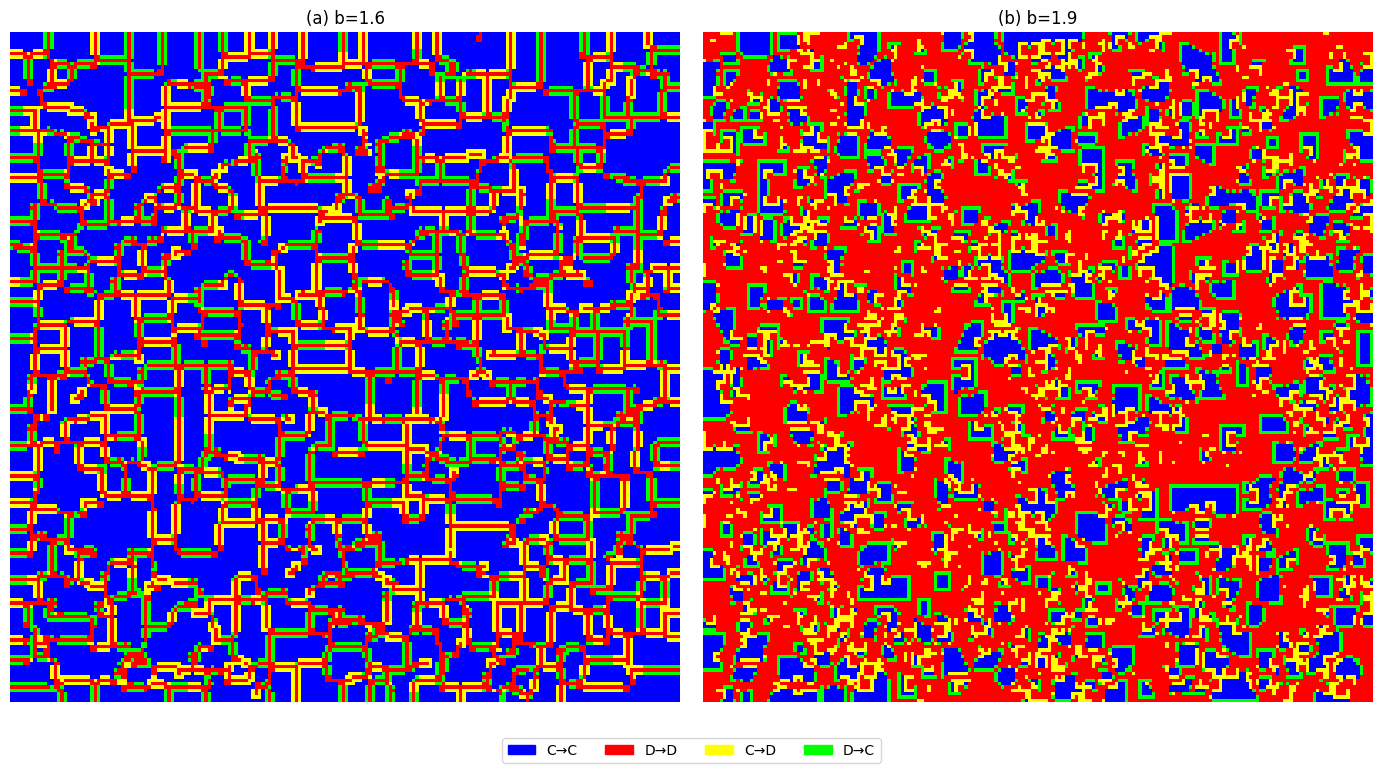

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
from matplotlib.patches import Patch

def simulate_spatial_pd(N, b, G, frac_coop=0.9, seed=0):
    np.random.seed(seed)
    grid = (np.random.rand(N, N) < frac_coop).astype(int)
    for _ in range(G):
        prev = grid
        pad = np.pad(prev, 1, mode='constant', constant_values=0)
        # count cooperating neighbors
        win = sliding_window_view(pad, (3, 3))
        coop_count = win.sum(axis=(2, 3))
        # payoff: cooperators get coop_count, defectors get b * coop_count
        payoff = np.where(prev==1, coop_count, b * coop_count)
        # find best neighbor
        pp = np.pad(payoff, 1, mode='constant', constant_values=-np.inf)
        ps = pad.copy()
        wpay   = sliding_window_view(pp, (3,3)).reshape(N, N, 9)
        wstate = sliding_window_view(ps, (3,3)).reshape(N, N, 9)
        idx = np.argmax(wpay, axis=2)
        i = np.arange(N)[:,None]; j = np.arange(N)[None,:]
        grid = wstate[i, j, idx]
    return prev, grid

N, G, seed = 200, 200, 0
b_values = [1.6, 1.9]
col_map = {
    (1,1): [0,0,1],  # C→C
    (0,0): [1,0,0],  # D→D
    (1,0): [1,1,0],  # C→D
    (0,1): [0,1,0],  # D→C
}

fig, axes = plt.subplots(1, 2, figsize=(14,7))
for ax, b, label in zip(axes, b_values, ['a','b']):
    prev, curr = simulate_spatial_pd(N, b, G, frac_coop=0.9, seed=seed)
    img = np.zeros((N, N, 3))
    for (p,c), rgb in col_map.items():
        img[(prev==p)&(curr==c)] = rgb
    ax.imshow(img, interpolation='nearest')
    ax.set_title(f'({label}) b={b}')
    ax.axis('off')

# legend
patches = [Patch(color=rgb, label=lbl) for (p,c), rgb, lbl in 
           zip(col_map.keys(), col_map.values(), ['C→C','D→D','C→D','D→C'])]
fig.legend(handles=patches, ncol=4, loc='upper center', bbox_to_anchor=(0.5,-0.02))

plt.tight_layout()
plt.show()
